In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

print(os.getcwd())
drive.mount("/content/drive")
sns.set_style("whitegrid")

df = pd.read_csv(
    "/content/drive/MyDrive/SE-dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv"
)

/content
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# SHAPE AND OVERVIEW


In [15]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== INFO ===")
print(df.info())

print("\n=== FIRST 5 ROWS ===")
df.head()

=== SHAPE ===
(246945, 378)

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), object(1)
memory usage: 712.2+ MB
None

=== FIRST 5 ROWS ===


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


# MISSING VALUES


In [16]:
print("=== MISSING VALUES ===")
print(df.isnull().sum().sum(), "total missing values")
print(df.isnull().sum()[df.isnull().sum() > 0])

=== MISSING VALUES ===
0 total missing values
Series([], dtype: int64)


# DUPLICATE ROWS


In [17]:
print("=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Unique rows: {df.shape[0] - df.duplicated().sum()}")

=== DUPLICATES ===
Duplicate rows: 57298
Unique rows: 189647


# DISEASE DISTRIBUTION


=== UNIQUE DISEASES ===
Total unique diseases: 773

=== TOP 20 DISEASES ===
diseases
cystitis                          1219
vulvodynia                        1218
nose disorder                     1218
complex regional pain syndrome    1217
spondylosis                       1216
esophagitis                       1215
conjunctivitis due to allergy     1215
hypoglycemia                      1215
peripheral nerve disorder         1215
vaginal cyst                      1215
diverticulitis                    1214
gastrointestinal hemorrhage       1214
acute bronchitis                  1213
pneumonia                         1212
fungal infection of the hair      1212
spontaneous abortion              1212
sprain or strain                  1212
infectious gastroenteritis        1212
gout                              1211
arthritis of the hip              1210
Name: count, dtype: int64

=== BOTTOM 20 DISEASES ===
diseases
diabetic kidney disease         2
hypergammaglobulinemia          1
open

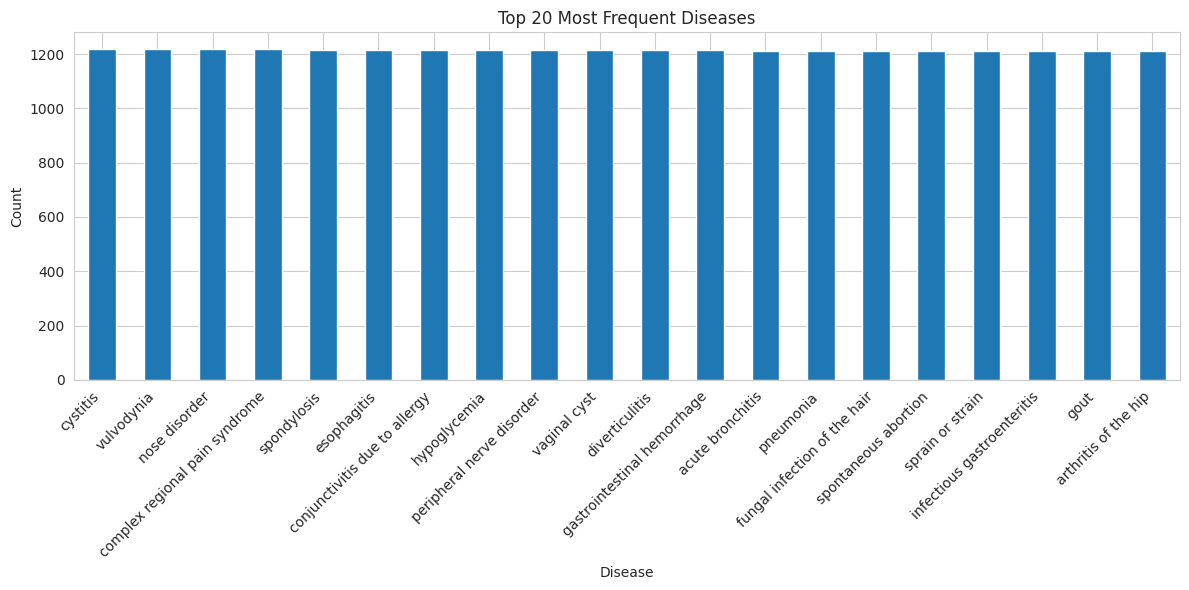

In [18]:
print("=== UNIQUE DISEASES ===")
print(f"Total unique diseases: {df['diseases'].nunique()}")

print("\n=== TOP 20 DISEASES ===")
print(df["diseases"].value_counts().head(20))

print("\n=== BOTTOM 20 DISEASES ===")
print(df["diseases"].value_counts().tail(20))

# Plot top 20
plt.figure(figsize=(12, 6))
df["diseases"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 Most Frequent Diseases")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# CLASS BALANCE


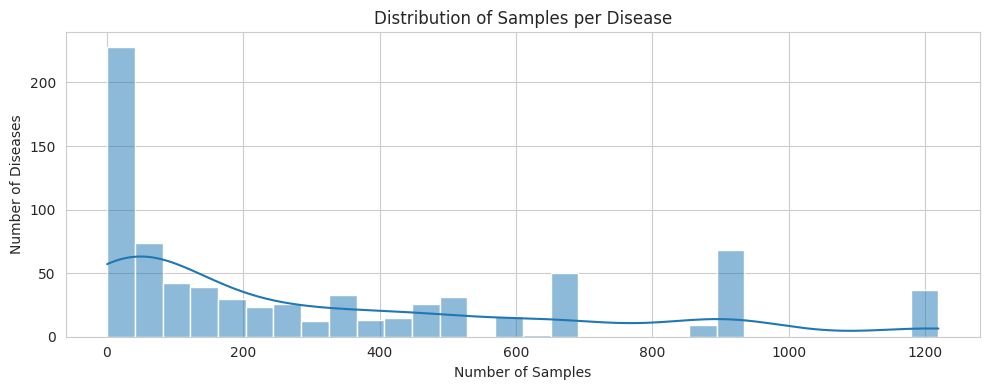

Mean samples per disease: 319.46
Min: 1 | Max: 1219


In [19]:
counts = df["diseases"].value_counts()

plt.figure(figsize=(10, 4))
sns.histplot(counts, bins=30, kde=True)
plt.title("Distribution of Samples per Disease")
plt.xlabel("Number of Samples")
plt.ylabel("Number of Diseases")
plt.tight_layout()
plt.show()

print(f"Mean samples per disease: {counts.mean():.2f}")
print(f"Min: {counts.min()} | Max: {counts.max()}")


# SYMPTOM FREQUENCY


=== TOP 20 MOST COMMON SYMPTOMS ===
sharp abdominal pain                32307
vomiting                            27874
headache                            24719
cough                               24296
sharp chest pain                    24016
nausea                              23687
back pain                           21809
shortness of breath                 21346
fever                               20394
dizziness                           17272
abnormal appearing skin             16425
nasal congestion                    16200
leg pain                            16189
skin swelling                       15165
depressive or psychotic symptoms    15064
lower abdominal pain                14936
sore throat                         14005
burning abdominal pain              12981
skin rash                           12375
skin lesion                         12340
dtype: int64

=== BOTTOM 20 RAREST SYMPTOMS ===
pus in sputum                   0
abnormal appearing tongue       0
nailbiti

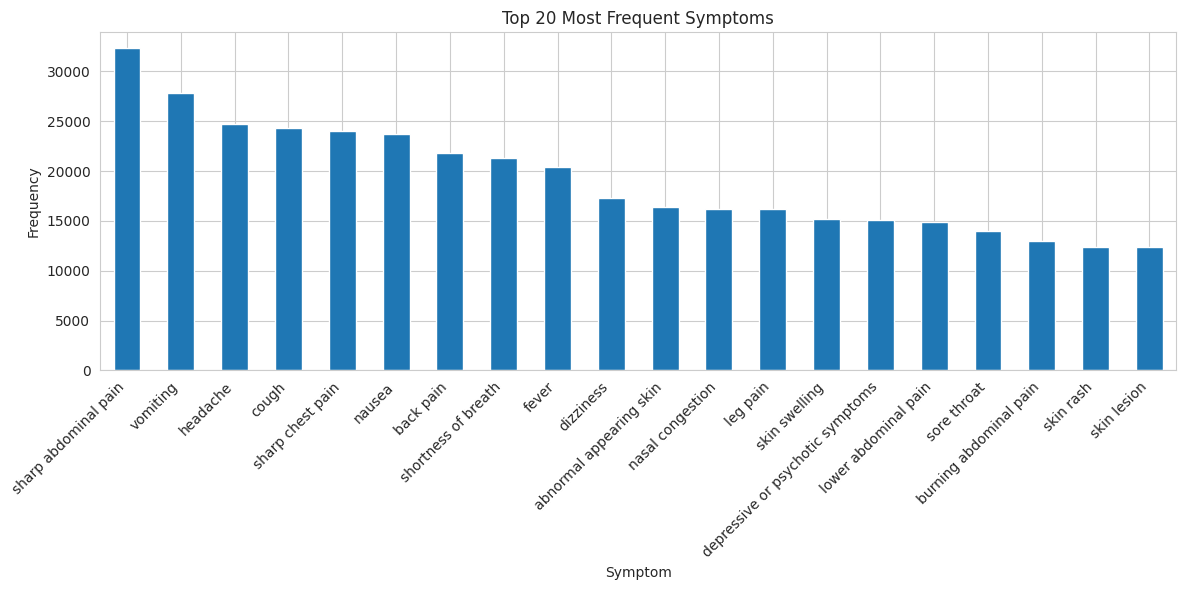

In [20]:
symptom_cols = df.columns[1:]
symptom_freq = df[symptom_cols].sum().sort_values(ascending=False)

print("=== TOP 20 MOST COMMON SYMPTOMS ===")
print(symptom_freq.head(20))

print("\n=== BOTTOM 20 RAREST SYMPTOMS ===")
print(symptom_freq.tail(20))

# Plot top 20
plt.figure(figsize=(12, 6))
symptom_freq.head(20).plot(kind="bar")
plt.title("Top 20 Most Frequent Symptoms")
plt.xlabel("Symptom")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# AVERAGE SYMPTOMS PER DISEASE


=== SYMPTOM COUNT PER ROW ===
count    246945.000000
mean          5.332851
std           1.640610
min           1.000000
25%           4.000000
50%           5.000000
75%           6.000000
max          12.000000
Name: symptom_count, dtype: float64


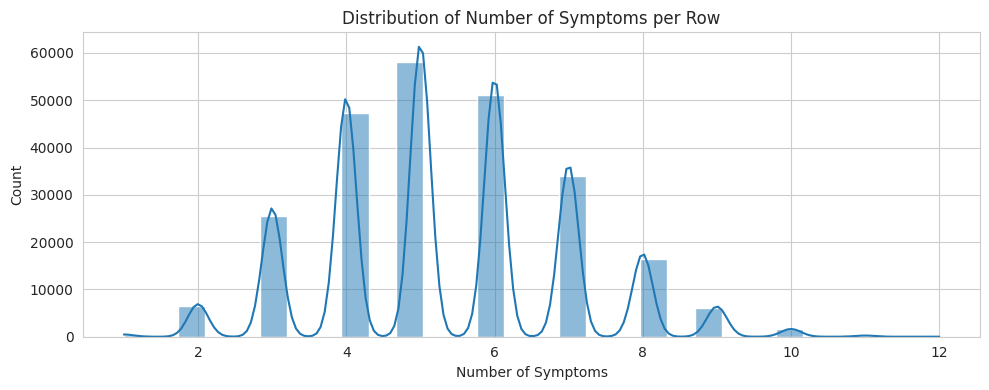


=== TOP 10 DISEASES BY AVG SYMPTOM COUNT ===
diseases
hiatal hernia                         6.300221
temporary or benign blood in urine    6.264214
anxiety                               6.095159
concussion                            6.090680
obstructive sleep apnea (osa)         6.086120
dental caries                         6.079325
injury to the leg                     6.076285
strep throat                          6.073554
acute bronchitis                      6.070899
marijuana abuse                       6.066942
Name: symptom_count, dtype: float64


In [21]:
df["symptom_count"] = df[symptom_cols].sum(axis=1)

print("=== SYMPTOM COUNT PER ROW ===")
print(df["symptom_count"].describe())

plt.figure(figsize=(10, 4))
sns.histplot(df["symptom_count"], bins=30, kde=True)
plt.title("Distribution of Number of Symptoms per Row")
plt.xlabel("Number of Symptoms")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Average per disease
avg_symptoms = (
    df.groupby("diseases")["symptom_count"].mean().sort_values(ascending=False)
)
print("\n=== TOP 10 DISEASES BY AVG SYMPTOM COUNT ===")
print(avg_symptoms.head(10))

# DUPLICATE COLUMN CHECK


In [22]:
print("=== CHECKING regurgitation vs regurgitation.1 ===")
print(df[["regurgitation", "regurgitation.1"]].head(10))
print("\nAre they identical?", df["regurgitation"].equals(df["regurgitation.1"]))

=== CHECKING regurgitation vs regurgitation.1 ===
   regurgitation  regurgitation.1
0              0                0
1              0                0
2              0                0
3              0                0
4              0                0
5              0                0
6              0                0
7              0                0
8              0                0
9              0                0

Are they identical? False


# CORRELATION HEATMAP (top symptoms only)


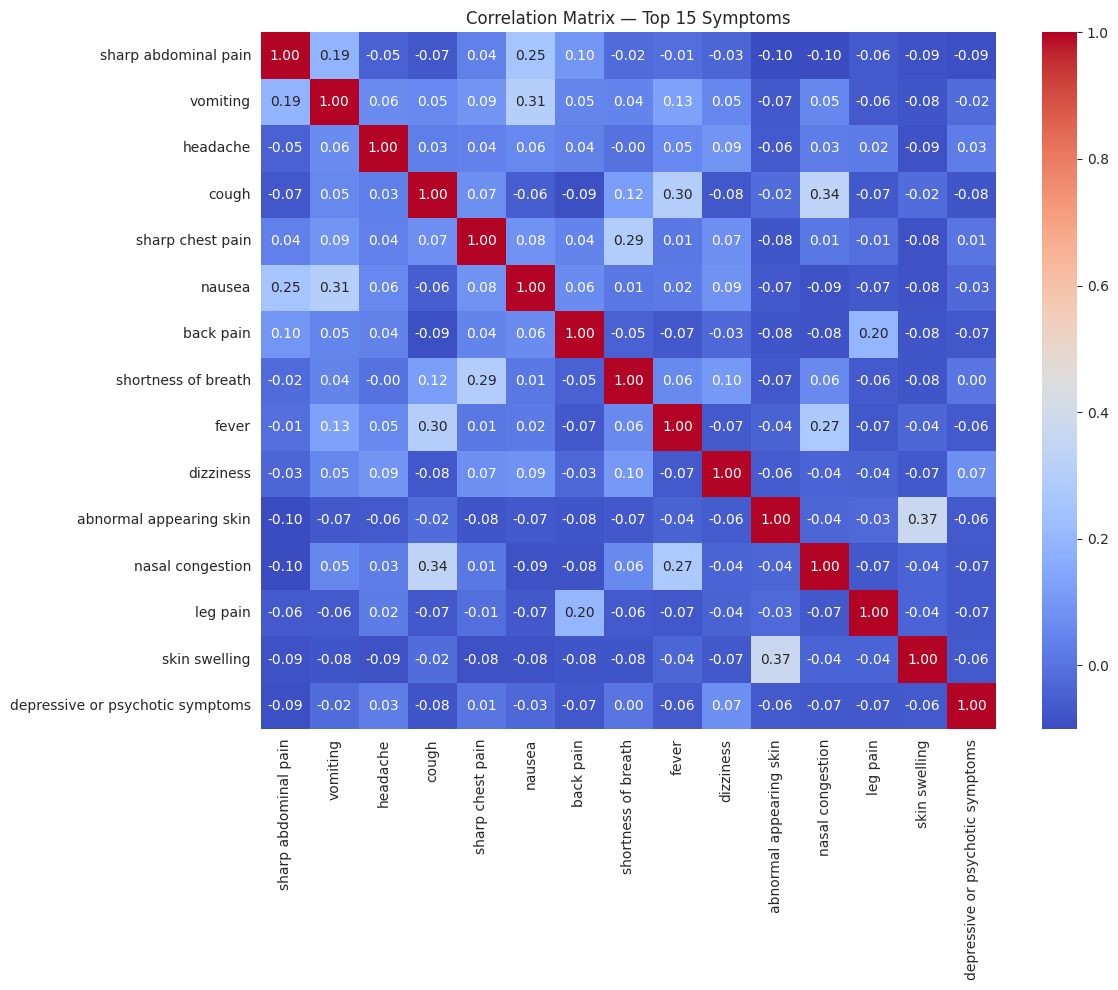

In [23]:
top_symptoms = symptom_freq.head(15).index.tolist()

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_symptoms].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix — Top 15 Symptoms")
plt.tight_layout()
plt.show()